# M07 — From regional signals to a graph: every edge is a choice

**Original guided lab · 75–100 minutes.** Read 20 min, predict/code 35 min, failure investigation 20 min, explain and transfer 15 min. Run all cells in order in a fresh kernel. All executed data are synthetic unless explicitly stated. No network, GPU, or external dataset is required.

A functional connectome is a representation of statistical relationships among signals. It is constructed from choices: atlas, extracted time series, nuisance model, time window, association measure, and edge-selection rule. A matrix image can look like a direct wiring diagram while actually summarizing correlations in processed BOLD. Structural connectivity and effective connectivity address different quantities; keep their names and measurement assumptions separate.

We construct six region signals driven by two module-specific processes and one shared nuisance process. Pearson correlation measures pairwise linear association after centering and scale normalization. The shared nuisance inflates correlations between modules even though their module-specific drives are independent. Removing a known shared drive changes the matrix. Real nuisance signals are estimated imperfectly and can overlap biological signals, so the toy correction is not a recommendation to regress every global component.

Partial association asks about a relationship after accounting for specified variables. Residualizing each signal against a known nuisance and correlating residuals provides one transparent example. Inverting an estimated covariance matrix supports another family of partial-correlation estimates, but high-dimensional covariance estimation requires regularization and adequate data. A partial correlation still does not by itself establish a direct causal connection: unmeasured common causes and model misspecification remain possible.

Turning a dense association matrix into a graph adds another transformation. An absolute threshold keeps edges above a chosen strength. A proportional threshold fixes density, retaining a chosen fraction. These strategies answer different questions, and both discard information. The sign policy matters: ignoring negative correlations, taking absolute values, or analyzing signed networks changes the object. Diagonal self-correlations should not accidentally become self-edges when calculating degree.

Our graph summary is intentionally simple: degree counts retained neighbors. Changing the threshold changes degree without changing the underlying participants or time series. More advanced metrics such as efficiency, modularity, and path length require additional conventions about weights, distances, disconnected nodes, and null models. A numerical graph score is therefore inseparable from the construction record.

Ask AI to print the matrix shape, diagonal, symmetry, unique edge count, threshold, and sign convention before computing an anatomical interpretation. The six toy region labels have no anatomy. For a real analysis, registration and atlas coverage need inspection before any network step; a perfectly computed graph can summarize misregistered or heavily contaminated signals. If groups differ in motion or retained time points, network differences can reflect measurement differences rather than biology.

## Transformation contract

Time×region signals `(500,6)` → raw/residual correlation matrices `(6,6)` → thresholded adjacency → degree `(6,)`. Correlation discards amplitude and timing details; thresholding discards weak edges; degree discards which nodes are connected.

## Ask your AI tutor

```text
Explain this notebook one transformation at a time.
Before each cell ask me to predict shapes, units, and a check.
Give edits in executable cells of at most 20 lines.
Keep the prescribed split, random seed, and tests intact.
Distinguish generated suggestions from executed results.
After the failure experiment, ask me to explain the mechanism.
```

In [1]:
import numpy as np
rng=np.random.default_rng(407)
module=rng.normal(size=(500,2));nuisance=rng.normal(size=500)
region_module=np.repeat([0,1],3)
X=module[:,region_module]+1.8*nuisance[:,None]+rng.normal(0,.35,(500,6))
C=np.column_stack([np.ones(500),nuisance])
residual=X-C@np.linalg.lstsq(C,X,rcond=None)[0]
raw=np.corrcoef(X,rowvar=False);clean=np.corrcoef(residual,rowvar=False)
print('Between-module mean correlation raw/residual:',raw[:3,3:].mean(),clean[:3,3:].mean())
assert raw[:3,3:].mean()>.6 and abs(clean[:3,3:].mean())<.15
assert np.allclose(clean,clean.T) and np.allclose(np.diag(clean),1)


Between-module mean correlation raw/residual: 0.7375466449426544 0.060287725234902


Threshold, unique edges, degree: 0.1 7 [2 2 3 2 3 2]
Threshold, unique edges, degree: 0.5 6 [2 2 2 2 2 2]
Threshold, unique edges, degree: 0.95 0 [0 0 0 0 0 0]


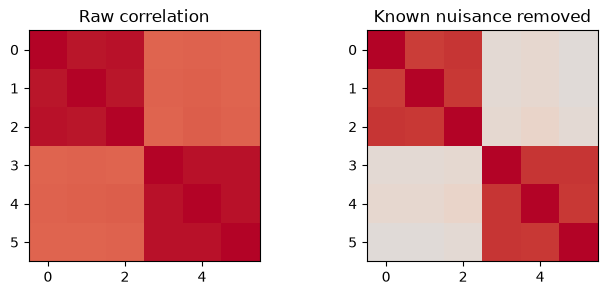

In [2]:
def adjacency(corr,threshold):
    A=corr>threshold
    np.fill_diagonal(A,False)
    return A
for threshold in [.1,.5,.95]:
    A=adjacency(clean,threshold)
    print('Threshold, unique edges, degree:',threshold,A.sum()//2,A.sum(axis=0))
    assert np.array_equal(A,A.T) and not A.diagonal().any()
assert adjacency(clean,.5).sum()>adjacency(clean,.95).sum()
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(8,3))
for a,M,title in zip(ax,[raw,clean],['Raw correlation','Known nuisance removed']):
    a.imshow(M,vmin=-1,vmax=1,cmap='coolwarm');a.set_title(title)
plt.show()


## Deliberate failure and repair

The shared drive creates strong between-module edges. Removing it works here because its identity is known from construction. Treating this as a universal global-signal regression prescription would be an unjustified transfer. A second failure is threshold shopping: choosing the threshold that maximizes a desired group difference makes the graph definition outcome-dependent.

## Your investigation

Create a graph construction record with atlas, signal extraction, nuisance model, association measure, edge threshold, negative-edge policy, and node exclusions. Compare weighted correlations with thresholded degrees. Explain why graph density changes can create differences in downstream graph metrics even without a distinct biological mechanism.

## Transfer to real neuroimaging

The BrainIAK tutorials progress from real masks and regions to connectivity-based prediction. They require data and potentially substantial memory; our six-region graph is a mechanics lab. Whole-brain graph inference, alternative covariance estimators, and group-level network statistics require separate validation and are not executed here.

**Primary teaching sources, pinned where hosted on GitHub:**

- [BrainIAK: seed and atlas connectivity](https://github.com/brainiak/brainiak-tutorials/blob/fb62ede943d9694fe703aee0df5f43ecf5558415/tutorials/08-connectivity.ipynb)
- [BrainIAK: full-correlation matrix analysis](https://github.com/brainiak/brainiak-tutorials/blob/fb62ede943d9694fe703aee0df5f43ecf5558415/tutorials/09-fcma.ipynb)

Pinned upstream tutorials are a separate assignment; they have **not been executed** by this core lab. They may require data downloads, specialist dependencies, unfinished student cells, and additional compute.

## Exit questions and answer key

1. Is functional correlation a tract? **No; it is a relationship between measured signals.**
2. Why remove diagonal entries before degree? **Self-correlation is not a retained between-node edge in this graph definition.**